#**AML LAB**

##**Experiment 12**

### Implement L1 (Lasso) and L2 (Ridge) regularization on the given Melbourne House Price Dataset. (Prepare Viva question on overfitting, underfitting and regularization)

### 1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LassoCV, RidgeCV

# Metrics
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)

print("All libraries imported successfully.")

All libraries imported successfully.


### 2. Load Dataset

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Applied_ML_Lab/Lab_8/dataset_Melbourne_housing_FULL_exp_12.csv')

print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nFirst 5 rows:")
df.head()

Dataset loaded: 34857 rows × 21 columns

First 5 rows:


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0


### 3. Exploratory Data Analysis (EDA)

In [ ]:
# 3.1 Dataset Structure
print("=" * 55)
print("DATASET SHAPE:", df.shape)
print("=" * 55)
df.info()

DATASET SHAPE: (34857, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         34857 non-null  object 
 1   Address        34857 non-null  object 
 2   Rooms          34857 non-null  int64  
 3   Type           34857 non-null  object 
 4   Price          27247 non-null  float64
 5   Method         34857 non-null  object 
 6   SellerG        34857 non-null  object 
 7   Date           34857 non-null  object 
 8   Distance       34856 non-null  float64
 9   Postcode       34856 non-null  float64
 10  Bedroom2       26640 non-null  float64
 11  Bathroom       26631 non-null  float64
 12  Car            26129 non-null  float64
 13  Landsize       23047 non-null  float64
 14  BuildingArea   13742 non-null  float64
 15  YearBuilt      15551 non-null  float64
 16  CouncilArea    34854 non-null  object 
 17  Lattitude      26881 no

In [ ]:
# 3.2 Statistical Summary
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
Rooms,34857.000000,3.031012,0.969933,1.000000,2.000000,3.000000,4.000000,16.000000
Price,27247.000000,1050173.344955,641467.130105,85000.000000,635000.000000,870000.000000,1295000.000000,11200000.000000
Distance,34856.000000,11.184929,6.788892,0.000000,6.400000,10.300000,14.000000,48.100000
Postcode,34856.000000,3116.062859,109.023903,3000.000000,3051.000000,3103.000000,3156.000000,3978.000000
Bedroom2,26640.000000,3.084647,0.980690,0.000000,2.000000,3.000000,4.000000,30.000000
Bathroom,26631.000000,1.624798,0.724212,0.000000,1.000000,2.000000,2.000000,12.000000
Car,26129.000000,1.728845,1.010771,0.000000,1.000000,2.000000,2.000000,26.000000
Landsize,23047.000000,593.598993,3398.841946,0.000000,224.000000,521.000000,670.000000,433014.000000
BuildingArea,13742.000000,160.256400,401.267060,0.000000,102.000000,136.000000,188.000000,44515.000000
YearBuilt,15551.000000,1965.289885,37.328178,1196.000000,1940.000000,1970.000000,2000.000000,2106.000000


Columns with missing values:
               Missing Count  Missing %
BuildingArea           21115      60.58
YearBuilt              19306      55.39
Landsize               11810      33.88
Car                     8728      25.04
Bathroom                8226      23.60
Bedroom2                8217      23.57
Lattitude               7976      22.88
Longtitude              7976      22.88
Price                   7610      21.83
Regionname                 3       0.01
CouncilArea                3       0.01
Propertycount              3       0.01
Distance                   1       0.00
Postcode                   1       0.00


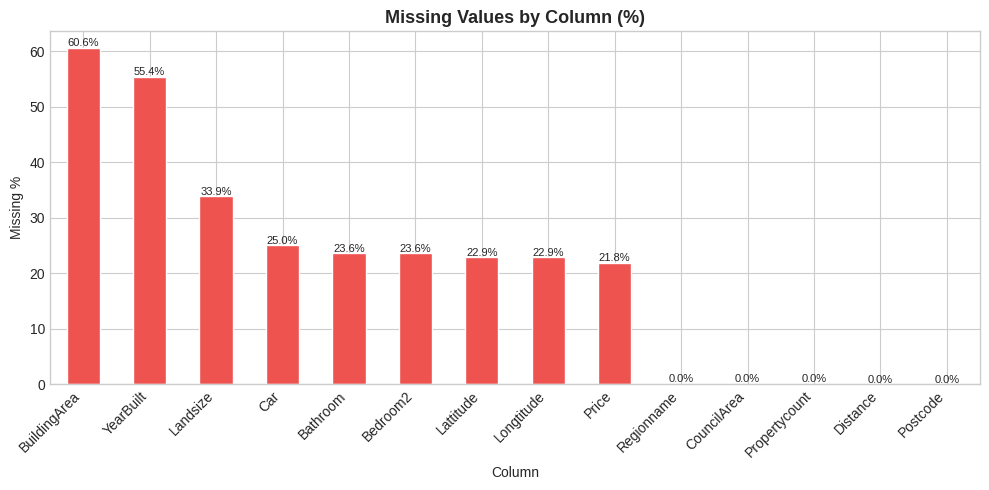

In [ ]:
# 3.3 Missing Values Analysis
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df  = missing_df[missing_df['Missing Count'] > 0]

print("Columns with missing values:")
print(missing_df.to_string())

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
missing_df['Missing %'].plot(kind='bar', color='#EF5350', edgecolor='white', ax=ax)
ax.set_title('Missing Values by Column (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Missing %')
ax.set_xlabel('Column')
plt.xticks(rotation=45, ha='right')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2, p.get_height() + 0.3),
                ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

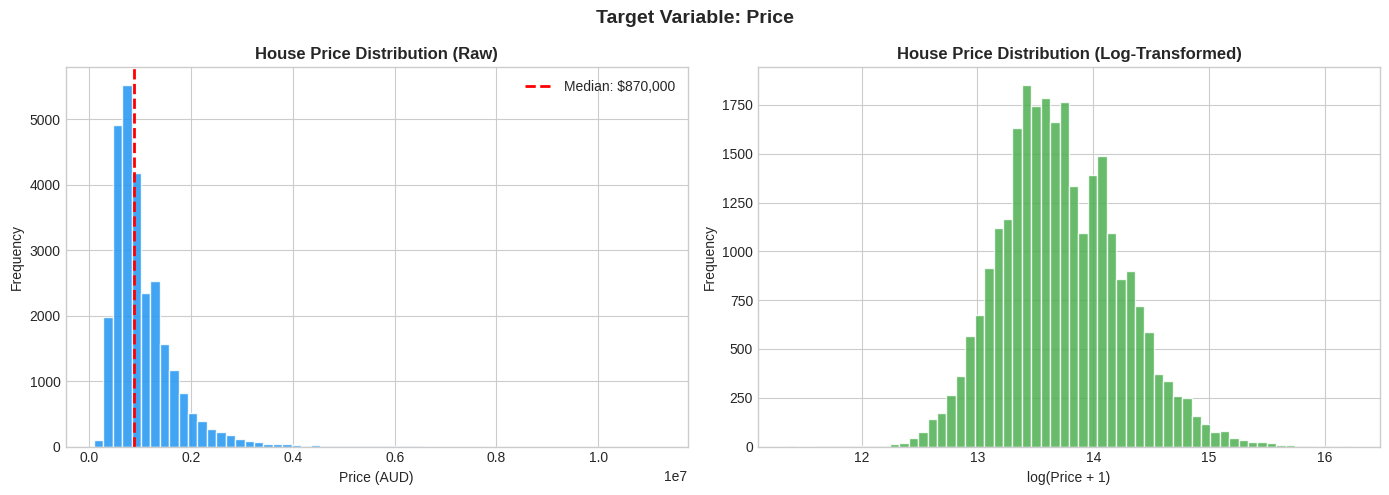

Price statistics:
  Min   : $      85,000
  Median: $     870,000
  Mean  : $   1,050,173
  Max   : $  11,200,000


In [ ]:
# 3.4 Target Variable Distribution
price_clean = df['Price'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(price_clean, bins=60, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].set_title('House Price Distribution (Raw)', fontweight='bold')
axes[0].set_xlabel('Price (AUD)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(price_clean.median(), color='red', linestyle='--', linewidth=2,
                label=f'Median: ${price_clean.median():,.0f}')
axes[0].legend()

# Log-transformed distribution (more normal)
axes[1].hist(np.log1p(price_clean), bins=60, color='#4CAF50', edgecolor='white', alpha=0.85)
axes[1].set_title('House Price Distribution (Log-Transformed)', fontweight='bold')
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Target Variable: Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Price statistics:")
print(f"  Min   : ${price_clean.min():>12,.0f}")
print(f"  Median: ${price_clean.median():>12,.0f}")
print(f"  Mean  : ${price_clean.mean():>12,.0f}")
print(f"  Max   : ${price_clean.max():>12,.0f}")

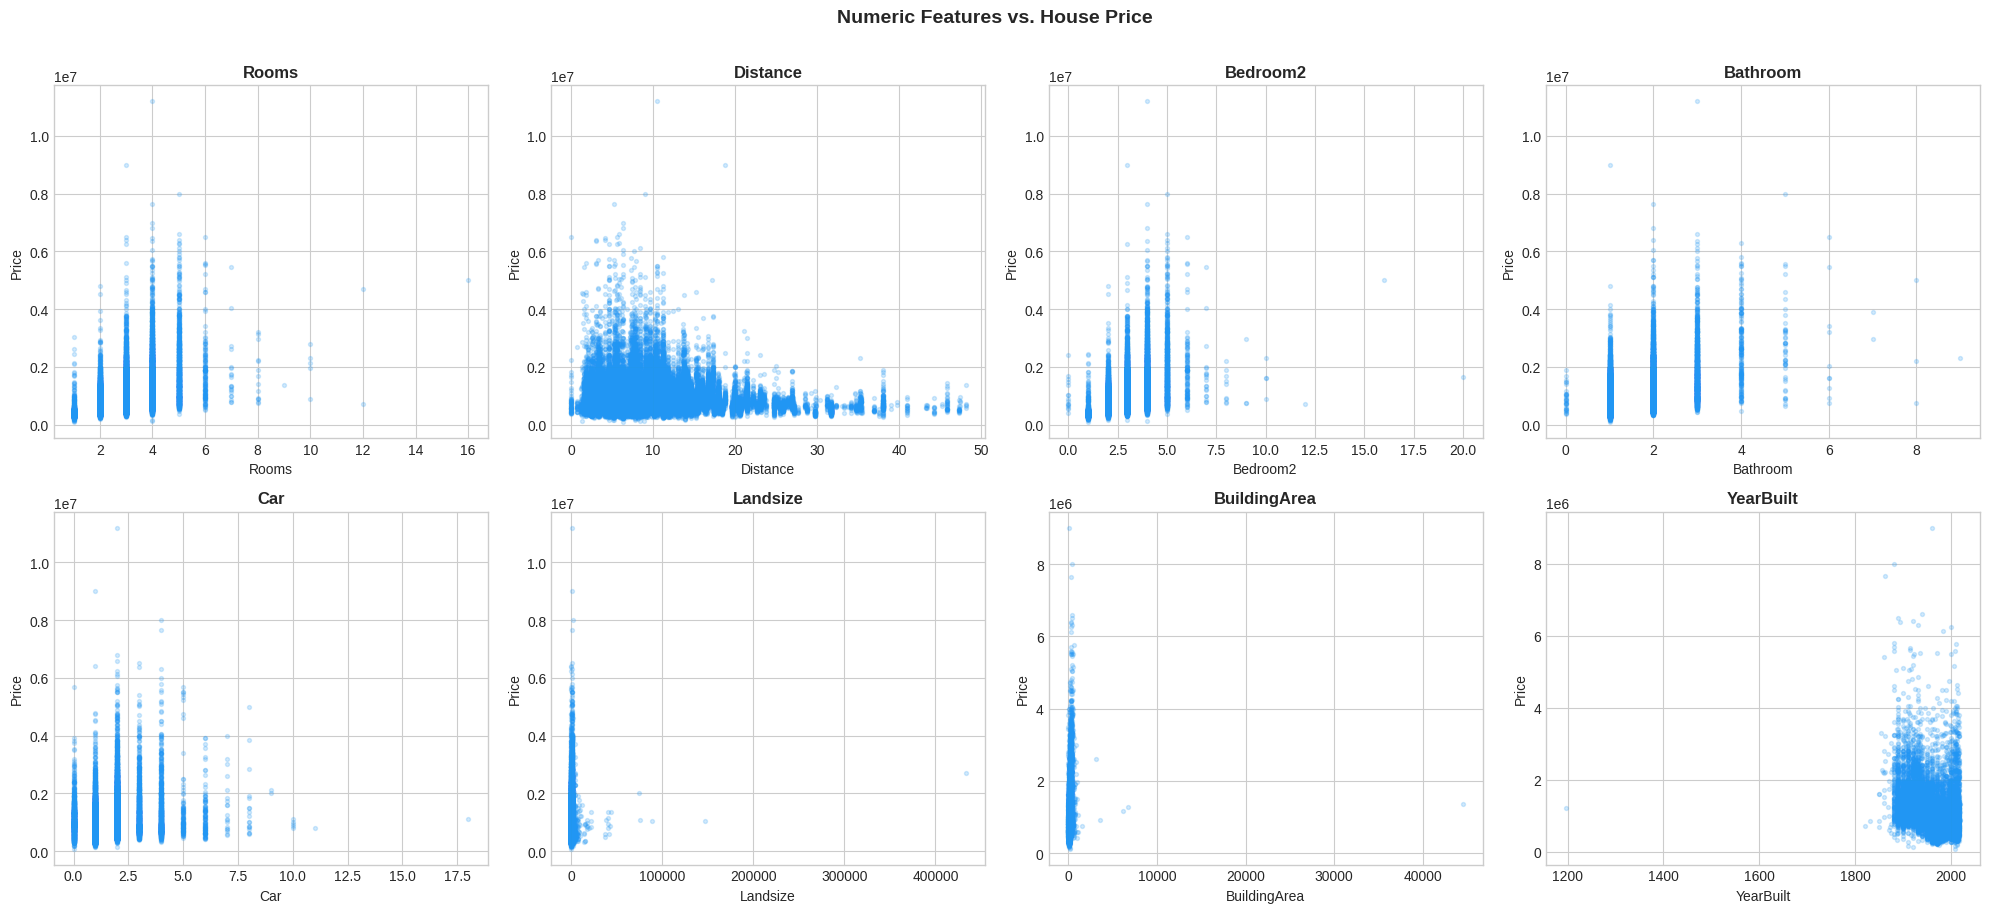

In [ ]:
# 3.5 Feature vs. Price Scatter Plots
num_features = ['Rooms', 'Distance', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.ravel()

temp = df.dropna(subset=['Price'])
for i, col in enumerate(num_features):
    axes[i].scatter(temp[col], temp['Price'], alpha=0.2, s=8, color='#2196F3')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Price')

plt.suptitle('Numeric Features vs. House Price', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

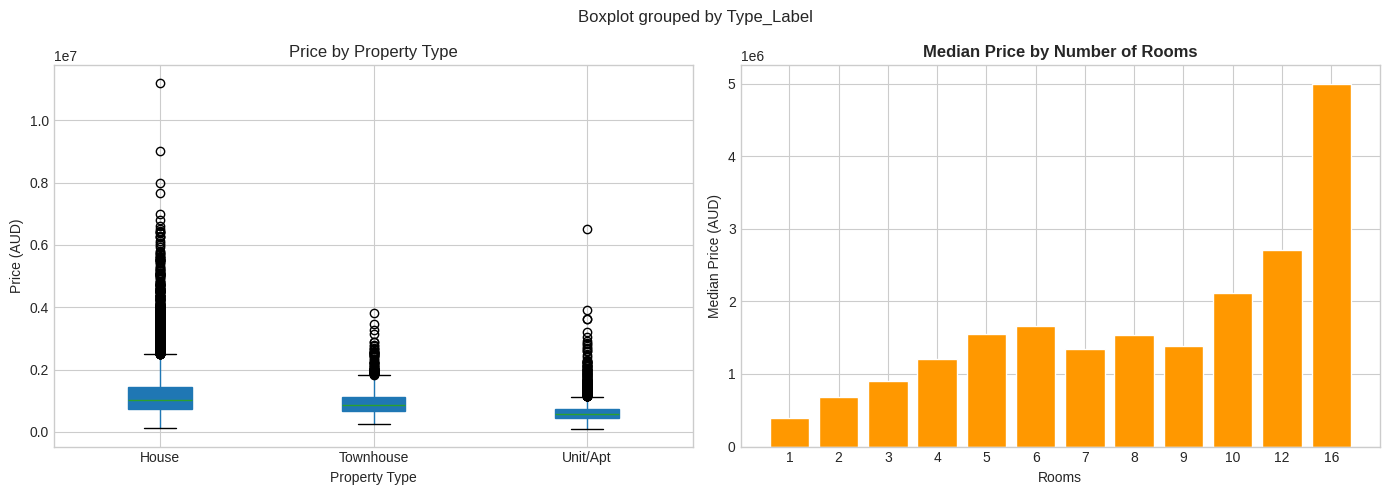

In [ ]:
# 3.6 Price by Property Type (Categorical)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

temp = df.dropna(subset=['Price'])

# Box by Type
type_labels = {'h': 'House', 'u': 'Unit/Apt', 't': 'Townhouse'}
temp_plot = temp.copy()
temp_plot['Type_Label'] = temp_plot['Type'].map(type_labels)
temp_plot.boxplot(column='Price', by='Type_Label', ax=axes[0],
                  patch_artist=True)
axes[0].set_title('Price by Property Type', fontweight='bold')
axes[0].set_xlabel('Property Type')
axes[0].set_ylabel('Price (AUD)')
plt.sca(axes[0])
plt.title('Price by Property Type')

# Median price by Rooms
room_price = temp.groupby('Rooms')['Price'].median().reset_index()
axes[1].bar(room_price['Rooms'].astype(str), room_price['Price'],
            color='#FF9800', edgecolor='white')
axes[1].set_title('Median Price by Number of Rooms', fontweight='bold')
axes[1].set_xlabel('Rooms')
axes[1].set_ylabel('Median Price (AUD)')

plt.tight_layout()
plt.savefig('categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

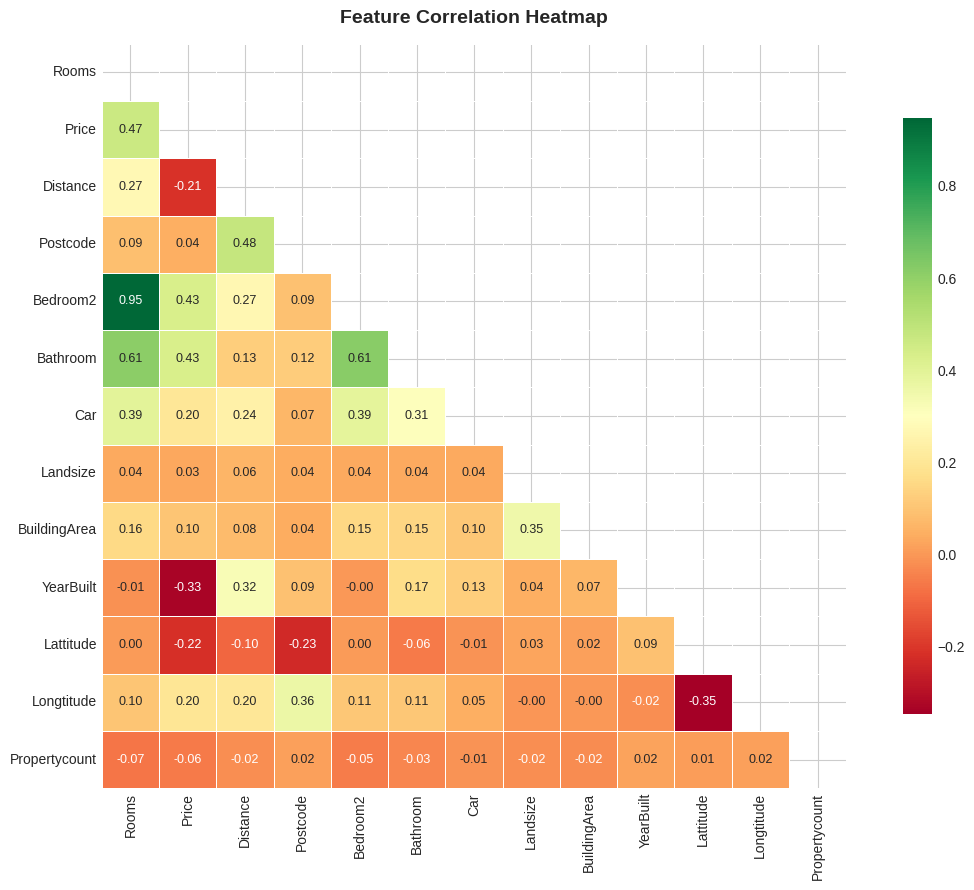


Top correlations with Price:
Rooms            0.465238
Bedroom2         0.430275
Bathroom         0.429878
Car              0.201803
Longtitude       0.197874
BuildingArea     0.100754
Postcode         0.044950
Landsize         0.032748
Propertycount   -0.059017
Distance        -0.211384
Lattitude       -0.215607
YearBuilt       -0.333306


In [ ]:
# 3.7 Correlation Heatmap
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop correlations with Price:")
print(corr['Price'].drop('Price').sort_values(ascending=False).to_string())

### 4. Data Preprocessing

In [ ]:
# 4.1 Drop Rows with Missing Target
df_clean = df.dropna(subset=['Price']).copy()
print(f"After dropping missing Price: {df_clean.shape}")

# 4.2 Drop High-Missing & Non-Informative Columns
drop_cols = ['BuildingArea', 'YearBuilt',   # >55% missing
             'Address', 'Date', 'SellerG',   # identifiers, not predictive
             'CouncilArea', 'Suburb']        # too many categories; lat/long captures location

df_clean.drop(columns=drop_cols, inplace=True)
print(f"After dropping columns: {df_clean.shape}")
print("Remaining columns:", list(df_clean.columns))

After dropping missing Price: (27247, 21)
After dropping columns: (27247, 14)
Remaining columns: ['Rooms', 'Type', 'Price', 'Method', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'Lattitude', 'Longtitude', 'Regionname', 'Propertycount']


In [ ]:
# 4.3 Encode Categorical Variables
cat_cols = ['Type', 'Method', 'Regionname']
le = LabelEncoder()

for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    print(f"  Label encoded: {col}")

print("\nCategorical encoding complete.")

  Label encoded: Type
  Label encoded: Method
  Label encoded: Regionname

Categorical encoding complete.


In [ ]:
# 4.4 Impute Remaining Missing Values (Numeric → Median)
print("Missing before imputation:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)

print("\nMissing after imputation:")
print(df_clean.isnull().sum().sum())
print("No missing values remain.")

Missing before imputation:
Distance            1
Postcode            1
Bedroom2         6441
Bathroom         6447
Car              6824
Landsize         9265
Lattitude        6254
Longtitude       6254
Propertycount       3
dtype: int64

Missing after imputation:
0
No missing values remain.


In [ ]:
# 4.5 Outlier Treatment (IQR Capping on Price and key features)
outlier_cols = ['Price', 'Landsize', 'Rooms', 'Bedroom2', 'Bathroom']

for col in outlier_cols:
    Q1, Q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    before = len(df_clean)
    df_clean[col] = df_clean[col].clip(lower, upper)
    print(f"  {col}: clipped to [{lower:.0f}, {upper:.0f}]")

print(f"\nFinal dataset shape: {df_clean.shape}")
print("Outlier treatment complete.")

  Price: clipped to [-355000, 2285000]
  Landsize: clipped to [-10, 954]
  Rooms: clipped to [-1, 7]
  Bedroom2: clipped to [3, 3]
  Bathroom: clipped to [-0, 4]

Final dataset shape: (27247, 14)
Outlier treatment complete.


### 5. Feature Engineering

In [ ]:
# 5.1 Log-transform the Target
df_clean['log_Price'] = np.log1p(df_clean['Price'])

# 5.2 Define Final Feature Set
# Drop original Price; drop Postcode (Lattitude/Longtitude already encode location)
X = df_clean.drop(columns=['Price', 'log_Price', 'Postcode'])
y = df_clean['log_Price']   # predict log-price (will exponentiate back for RMSE)

print("Feature matrix X:", X.shape)
print("Target y (log_Price):", y.shape)
print("\nFeatures:", list(X.columns))

Feature matrix X: (27247, 12)
Target y (log_Price): (27247,)

Features: ['Rooms', 'Type', 'Method', 'Distance', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'Lattitude', 'Longtitude', 'Regionname', 'Propertycount']


### 6. Train-Test Split

In [ ]:
# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")

Training set : 21797 samples
Test set     : 5450 samples


### 7. Model Training

In [ ]:
# 7.1 Auto-Tune Alpha via Cross-Validation
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# LassoCV automatically selects optimal alpha via 5-fold CV
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)
best_lasso_alpha = lasso_cv.alpha_

# RidgeCV automatically selects optimal alpha
alphas_ridge = np.logspace(-3, 5, 100)
ridge_cv = RidgeCV(alphas=alphas_ridge, cv=5)
ridge_cv.fit(X_train_scaled, y_train)
best_ridge_alpha = ridge_cv.alpha_

print(f"Optimal Lasso alpha (LassoCV): {best_lasso_alpha:.6f}")
print(f"Optimal Ridge alpha (RidgeCV): {best_ridge_alpha:.4f}")

Optimal Lasso alpha (LassoCV): 0.000260
Optimal Ridge alpha (RidgeCV): 27.8256


In [ ]:
# 7.2 Build & Train Final Pipelines
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipe_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=best_lasso_alpha, max_iter=10000, random_state=42))
])

pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=best_ridge_alpha))
])

models = {
    'Linear Regression (Baseline)': pipe_lr,
    'Lasso (L1)': pipe_lasso,
    'Ridge (L2)': pipe_ridge
}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    print(f"{name} — trained.")

print("\nAll models trained successfully.")

Linear Regression (Baseline) — trained.
Lasso (L1) — trained.
Ridge (L2) — trained.

All models trained successfully.


### 8. Model Evaluation

In [ ]:
# Compute Metrics (in original AUD scale via expm1)
results = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, pipe in models.items():
    y_pred_log = pipe.predict(X_test)

    # Back-transform log predictions to original price scale
    y_pred_orig = np.expm1(y_pred_log)
    y_test_orig = np.expm1(y_test)

    mae  = mean_absolute_error(y_test_orig, y_pred_orig)
    mse  = mean_squared_error(y_test_orig, y_pred_orig)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test_orig, y_pred_orig)

    # CV R² on log scale
    cv_r2 = cross_val_score(pipe, X, y, cv=kf, scoring='r2').mean()

    results[name] = {
        'MAE':       mae,
        'MSE':       mse,
        'RMSE':      rmse,
        'R²':        r2,
        'CV R²':     cv_r2,
        'y_pred':    y_pred_log,
        'y_pred_orig': y_pred_orig
    }

    print(f"\n── {name} ──")
    print(f"   MAE  : ${mae:>12,.0f}")
    print(f"   RMSE : ${rmse:>12,.0f}")
    print(f"   R²   :  {r2:.4f}")
    print(f"   CV R²:  {cv_r2:.4f}")

print("\nEvaluation complete.")


── Linear Regression (Baseline) ──
   MAE  : $     232,038
   RMSE : $     320,173
   R²   :  0.6003
   CV R²:  0.6263

── Lasso (L1) ──
   MAE  : $     232,120
   RMSE : $     320,300
   R²   :  0.6000
   CV R²:  0.6263

── Ridge (L2) ──
   MAE  : $     232,110
   RMSE : $     320,273
   R²   :  0.6001
   CV R²:  0.6263

Evaluation complete.


### 9. Visualizations

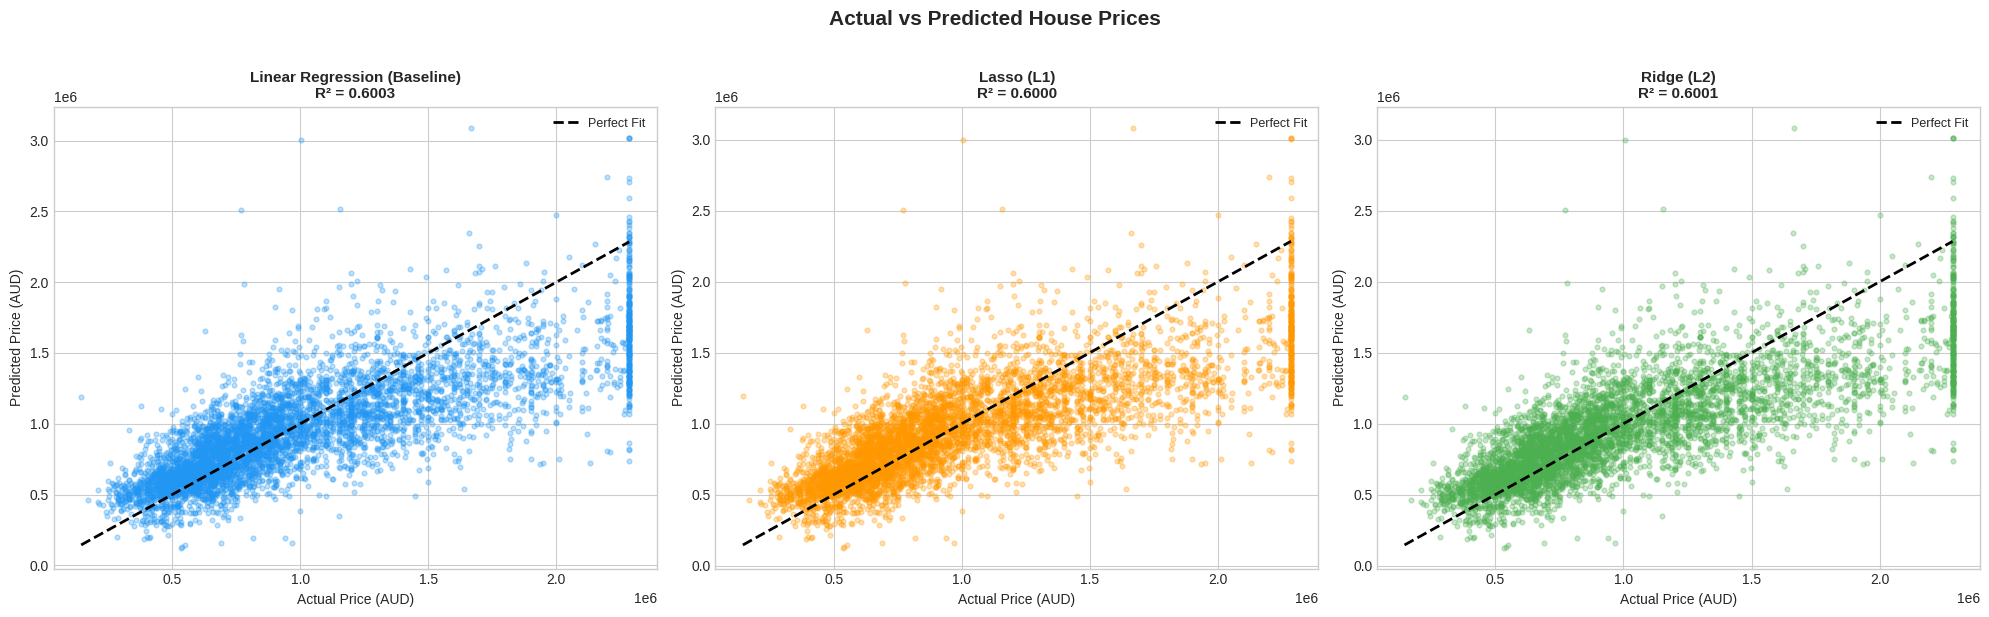

In [ ]:
# 9.1 Actual vs Predicted Plots
model_colors = ['#2196F3', '#FF9800', '#4CAF50']
y_test_orig  = np.expm1(y_test)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, res), color in zip(axes, results.items(), model_colors):
    ax.scatter(y_test_orig, res['y_pred_orig'],
               alpha=0.3, s=12, color=color)
    # Perfect prediction line
    lims = [y_test_orig.min(), y_test_orig.max()]
    ax.plot(lims, lims, 'k--', linewidth=2, label='Perfect Fit')
    ax.set_xlabel('Actual Price (AUD)', fontsize=10)
    ax.set_ylabel('Predicted Price (AUD)', fontsize=10)
    ax.set_title(f'{name}\nR² = {res["R²"]:.4f}', fontweight='bold', fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle('Actual vs Predicted House Prices', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

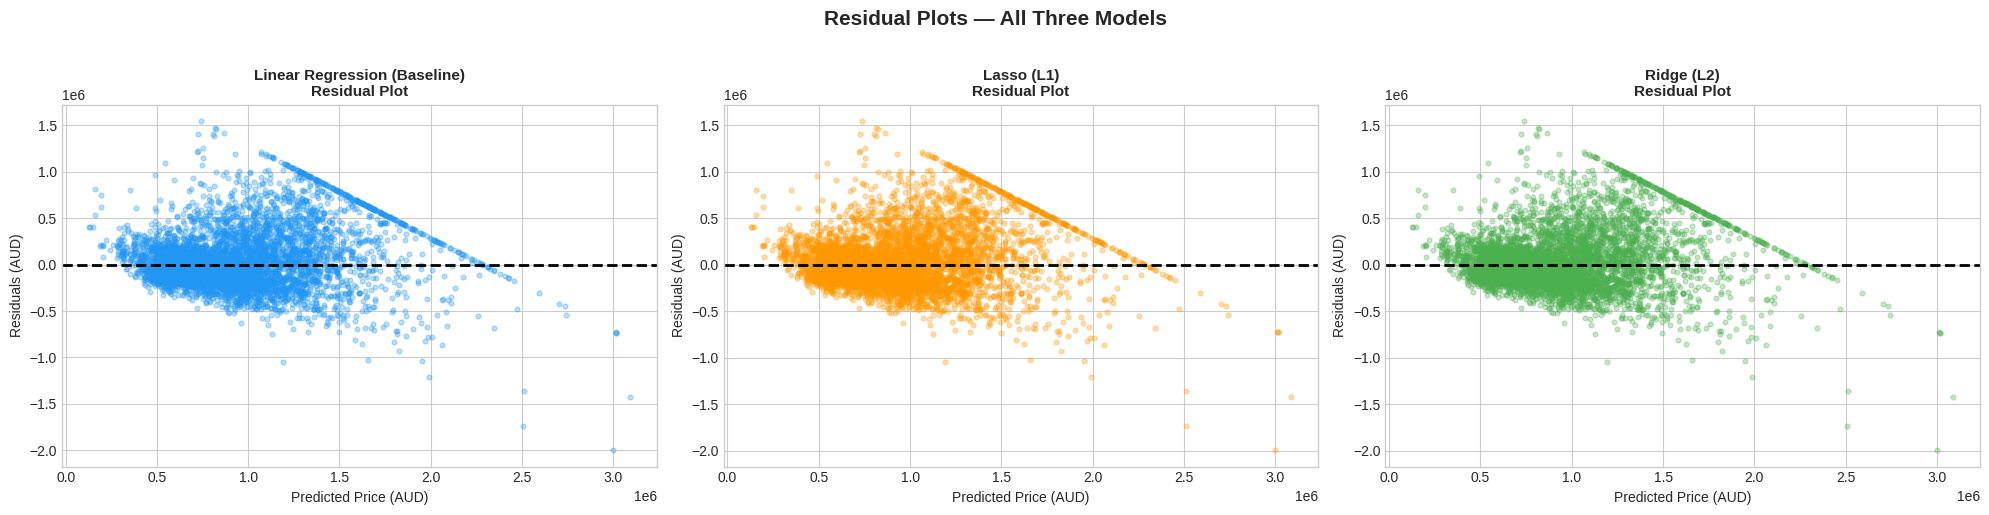

In [ ]:
# 9.2 Residual Plots
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (name, res), color in zip(axes, results.items(), model_colors):
    residuals = np.expm1(y_test) - res['y_pred_orig']
    ax.scatter(res['y_pred_orig'], residuals,
               alpha=0.3, s=12, color=color)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=2)
    ax.set_xlabel('Predicted Price (AUD)', fontsize=10)
    ax.set_ylabel('Residuals (AUD)', fontsize=10)
    ax.set_title(f'{name}\nResidual Plot', fontweight='bold', fontsize=11)

plt.suptitle('Residual Plots — All Three Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('residual_plots.png', dpi=150, bbox_inches='tight')
plt.show()

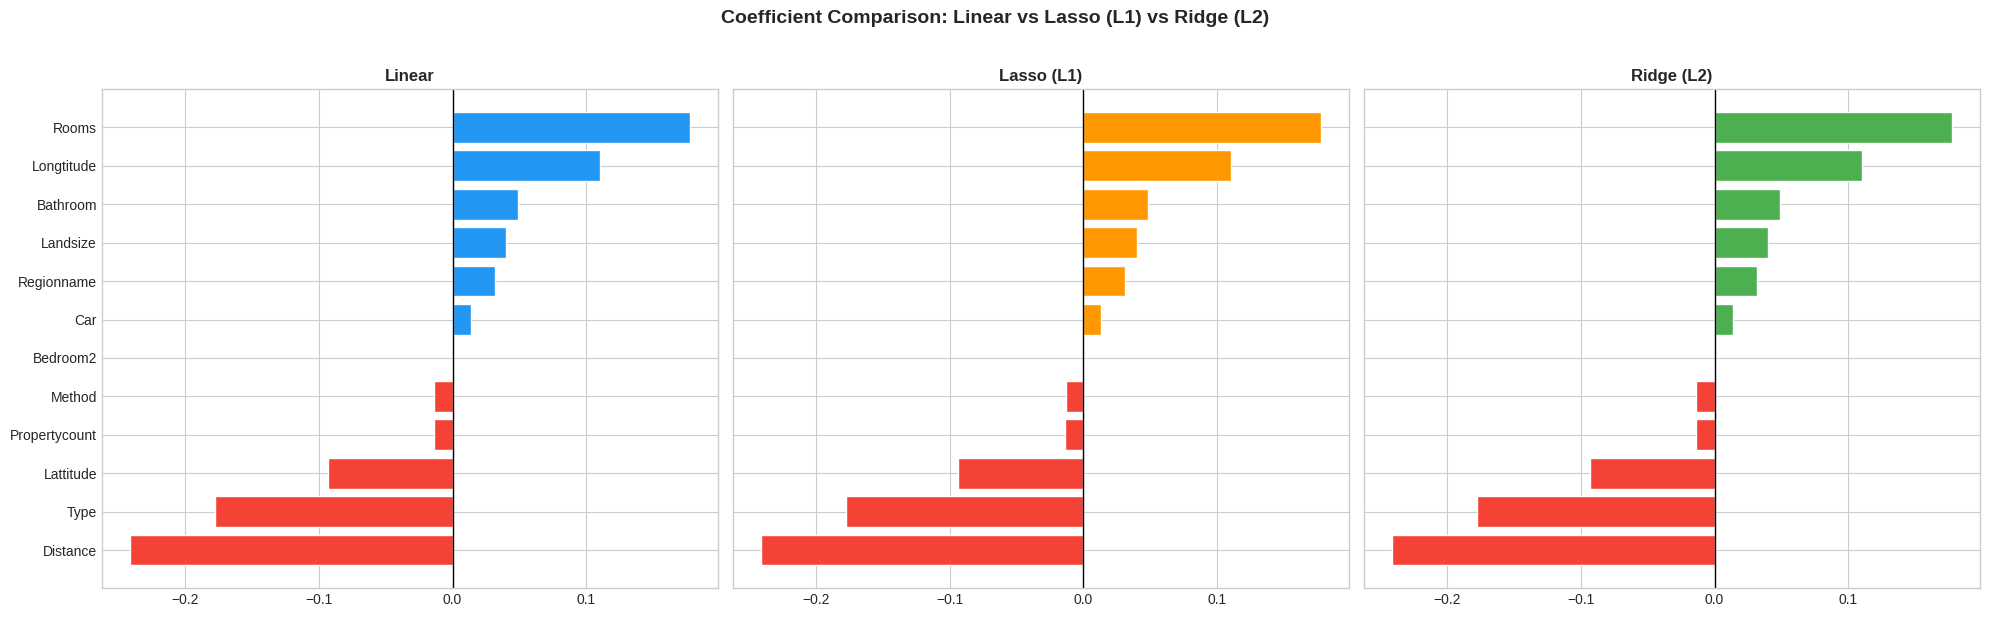

Features driven to ZERO by Lasso: 1/12
Eliminated features: ['Bedroom2']


In [ ]:
# 9.3 Coefficient Comparison: Lasso vs Ridge vs Linear
feature_names = list(X.columns)

coef_lr    = pipe_lr.named_steps['model'].coef_
coef_lasso = pipe_lasso.named_steps['model'].coef_
coef_ridge = pipe_ridge.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Linear'     : coef_lr,
    'Lasso (L1)' : coef_lasso,
    'Ridge (L2)' : coef_ridge
}).set_index('Feature')

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for ax, col, color in zip(axes,
                           ['Linear', 'Lasso (L1)', 'Ridge (L2)'],
                           model_colors):
    vals = coef_df[col].sort_values()
    colors_bar = ['#F44336' if v < 0 else color for v in vals]
    axes[0 if col == 'Linear' else (1 if col == 'Lasso (L1)' else 2)].barh(
        vals.index, vals.values, color=colors_bar, edgecolor='white'
    )
    axes[0 if col == 'Linear' else (1 if col == 'Lasso (L1)' else 2)].axvline(0, color='black', linewidth=1)
    axes[0 if col == 'Linear' else (1 if col == 'Lasso (L1)' else 2)].set_title(
        col, fontweight='bold', fontsize=12)

plt.suptitle('Coefficient Comparison: Linear vs Lasso (L1) vs Ridge (L2)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('coefficients_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Show zero coefficients (Lasso feature selection)
zero_feats = (coef_df['Lasso (L1)'] == 0).sum()
print(f"Features driven to ZERO by Lasso: {zero_feats}/{len(feature_names)}")
print("Eliminated features:", list(coef_df[coef_df['Lasso (L1)'] == 0].index))

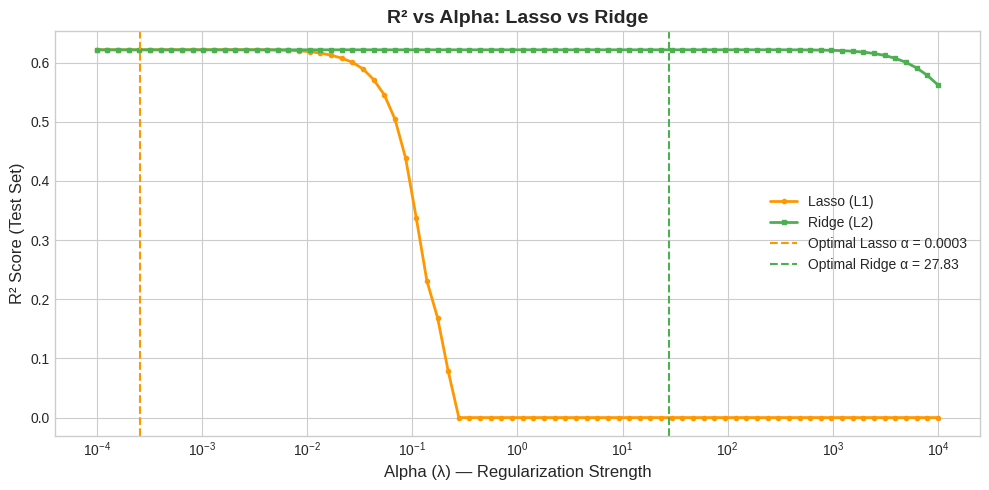

In [ ]:
# 9.4 Regularization Path: Effect of Alpha on R²
alphas = np.logspace(-4, 4, 80)
lasso_r2, ridge_r2 = [], []

scaler_path = StandardScaler()
X_tr_s = scaler_path.fit_transform(X_train)
X_te_s = scaler_path.transform(X_test)

for alpha in alphas:
    l = Lasso(alpha=alpha, max_iter=10000).fit(X_tr_s, y_train)
    lasso_r2.append(r2_score(y_test, l.predict(X_te_s)))

    r = Ridge(alpha=alpha).fit(X_tr_s, y_train)
    ridge_r2.append(r2_score(y_test, r.predict(X_te_s)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(alphas, lasso_r2, '-o', markersize=3, color='#FF9800',
            linewidth=2, label='Lasso (L1)')
ax.semilogx(alphas, ridge_r2, '-s', markersize=3, color='#4CAF50',
            linewidth=2, label='Ridge (L2)')
ax.axvline(best_lasso_alpha, color='#FF9800', linestyle='--',
           linewidth=1.5, label=f'Optimal Lasso α = {best_lasso_alpha:.4f}')
ax.axvline(best_ridge_alpha, color='#4CAF50', linestyle='--',
           linewidth=1.5, label=f'Optimal Ridge α = {best_ridge_alpha:.2f}')
ax.set_xlabel('Alpha (λ) — Regularization Strength', fontsize=12)
ax.set_ylabel('R² Score (Test Set)', fontsize=12)
ax.set_title('R² vs Alpha: Lasso vs Ridge', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('alpha_path.png', dpi=150, bbox_inches='tight')
plt.show()

### 10. Model Comparison Table

In [ ]:
# Final Comparison Table
metric_keys = ['MAE', 'MSE', 'RMSE', 'R²', 'CV R²']

comparison_df = pd.DataFrame(
    {name: {k: results[name][k] for k in metric_keys} for name in results}
).T

# Format for display
comparison_display = comparison_df.copy()
comparison_display['MAE']  = comparison_display['MAE'].map('${:,.0f}'.format)
comparison_display['MSE']  = comparison_display['MSE'].map('{:.3e}'.format)
comparison_display['RMSE'] = comparison_display['RMSE'].map('${:,.0f}'.format)
comparison_display['R²']   = comparison_display['R²'].map('{:.4f}'.format)
comparison_display['CV R²']= comparison_display['CV R²'].map('{:.4f}'.format)

print("\nMODEL COMPARISON TABLE\n")
print(comparison_display.to_string())


MODEL COMPARISON TABLE

                                   MAE        MSE      RMSE      R²   CV R²
Linear Regression (Baseline)  $232,038  1.025e+11  $320,173  0.6003  0.6263
Lasso (L1)                    $232,120  1.026e+11  $320,300  0.6000  0.6263
Ridge (L2)                    $232,110  1.026e+11  $320,273  0.6001  0.6263


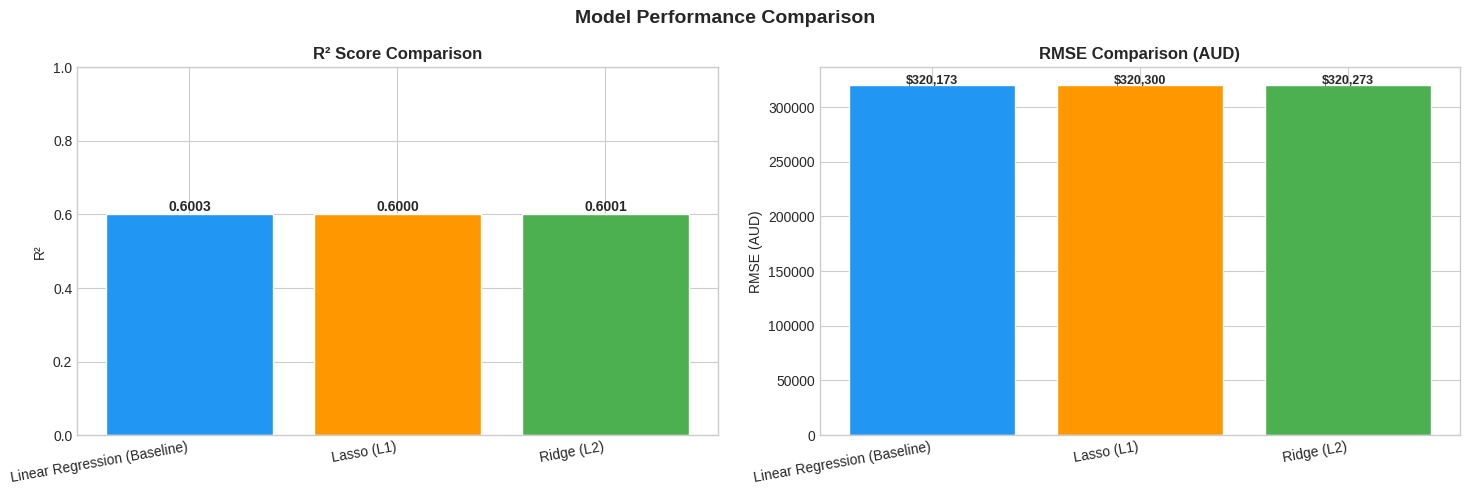

In [ ]:
# Comparison Bar Charts
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# R² comparison
r2_vals = [results[m]['R²'] for m in results]
axes[0].bar(list(results.keys()), r2_vals, color=model_colors, edgecolor='white')
axes[0].set_ylim(0, 1)
axes[0].set_title('R² Score Comparison', fontweight='bold', fontsize=12)
axes[0].set_ylabel('R²')
for i, v in enumerate(r2_vals):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

# RMSE comparison
rmse_vals = [results[m]['RMSE'] for m in results]
axes[1].bar(list(results.keys()), rmse_vals, color=model_colors, edgecolor='white')
axes[1].set_title('RMSE Comparison (AUD)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('RMSE (AUD)')
for i, v in enumerate(rmse_vals):
    axes[1].text(i, v + 1000, f'${v:,.0f}', ha='center', fontweight='bold', fontsize=9)

for ax in axes:
    ax.set_xticklabels(list(results.keys()), rotation=10, ha='right')

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 11. Conclusion & Analysis

In [ ]:
# Best Model
best_model = comparison_df['R²'].idxmax()
best_r2    = comparison_df['R²'].max()
best_rmse  = comparison_df.loc[best_model, 'RMSE']

print(f"BEST MODEL  :  {best_model:<30}")
print(f"R² Score       :  {best_r2:.4f}")
print(f"RMSE           :  ${best_rmse:>10,.0f}")

print("\nFull Comparison:")
print(comparison_df.to_string())

BEST MODEL  :  Linear Regression (Baseline)  
R² Score       :  0.6003
RMSE           :  $   320,173

Full Comparison:
                                        MAE           MSE           RMSE        R²     CV R²
Linear Regression (Baseline)  232038.191167  1.025106e+11  320172.797884  0.600316  0.626333
Lasso (L1)                    232120.181944  1.025919e+11  320299.759207  0.599999  0.626333
Ridge (L2)                    232109.706501  1.025748e+11  320273.041514  0.600066  0.626335
